# MNIST digit classification with pytorch

In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

## pytorch - tensors and devices
We could create native tensors using torch - first dimension is the batch dimension, meaning that in this tensor we have 5 entries of 3 dimensional vector data

In [2]:
torch.randn(5, 2, 3)

tensor([[[ 0.4678,  1.1107,  1.0894],
         [-0.1417, -0.0581,  1.3891]],

        [[-0.8405, -1.4909, -1.1232],
         [-1.7729,  1.1356,  1.3571]],

        [[ 2.2143, -1.5621, -1.0658],
         [-0.3139, -0.0181,  0.0881]],

        [[ 0.8326, -2.0370,  0.4514],
         [-1.0167,  0.1575,  0.9855]],

        [[ 0.5160, -0.3810,  0.0066],
         [-0.8717, -0.8921,  0.0032]]])

It is also possible to convert numpy arrays into tensors. This wraps the original data (write in place) and does not consume extra memory. Same behaviour with `torch.as_tensor()` that accepts inputs other than numpy arrays. 

In [3]:
torch.from_numpy(np.random.normal(0,1,(5,3)))

tensor([[ 0.7597,  0.1211,  0.5117],
        [ 1.7307, -0.4447,  0.0853],
        [-0.1185, -1.0497, -0.3624],
        [ 1.7256, -0.6582, -0.4212],
        [-0.9862,  1.1832,  0.4836]], dtype=torch.float64)

**Warning:** These functions preserve the 64-bit floats of numpy, note that dtype is specified in the representations above - the default dtype for tensors in pytorch torch.float32 and we must make sure the tensors and the models we use match in dtype. Use `.float()` method to convert to native pytorch dtype - (note that it does not specifically show dtype now)

In [4]:
torch.from_numpy(np.random.normal(0,1,(5,3))).float()

tensor([[-0.1642,  1.6919,  0.5967],
        [-0.0163,  1.0597, -0.6287],
        [ 1.6885, -1.3971, -0.7619],
        [-0.7033, -0.4249,  1.5544],
        [-0.9630,  0.3341, -0.8397]])

We now specify which framework we use for computation. By default, pytorch keeps the model and the data as tensors on the RAM, and labeled to be processed by the CPU. If the GPU framework is supported, we use `.to(device)` method to copy the tensors to the VRAM, to be processed by GPU. In special cases where the CPU and GPU share the memory, (Apple Silicon MPS framework is an example) - tensors stay in the same place but gets flagged to be processed by the GPU when we run `.to(device)` on them.

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## loading the data, batches!
In pytorch the `Dataset` class is used to store the tensors along with their labels and it can be fed into a model using the `DataLoader` iterable. A custom Dataset for handling a pandas dataframe looks like this:

In [6]:
class PandasDataset(Dataset):
    def __init__(self, df, feature_cols, target_col):
        self.X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.Y = torch.tensor(df[target_col].values, dtype=torch.float32)
        
        # this introduces the batch dimension for both features and targets 
        self.X = self.X.view(len(self.X), -1) 
        self.Y = self.Y.view(len(self.Y), -1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # this returns the data as tensors, given the requested batch indices idx
        return self.X[idx], self.Y[idx]

generate an example pandas dataframe

In [7]:
N = 200
x = (np.sort(np.random.random_sample(N))-0.5)*2
f = lambda x: x**7 + np.random.random_sample(N)*(0.5*x + 0.2)
y = f(x)
df = pd.DataFrame({'x': x, 'y':y})
dataset = PandasDataset(df,['x'],['y'])
loader = DataLoader(dataset, batch_size=4)

`__iter__` method of DataLoader returns an iterator which returns batch tensors for features and targets every time we poll it

In [8]:
next(iter(loader))

[tensor([[-0.9817],
         [-0.9811],
         [-0.9738],
         [-0.9722]]),
 tensor([[-1.0425],
         [-1.1552],
         [-0.8517],
         [-1.1000]])]

## image data
let's look at some datasets that exist in the **torchvision** library, image and video processing library from the pytorch ecosystem

In [9]:
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
);

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
);

lets look at a batch of size 4 from the test data

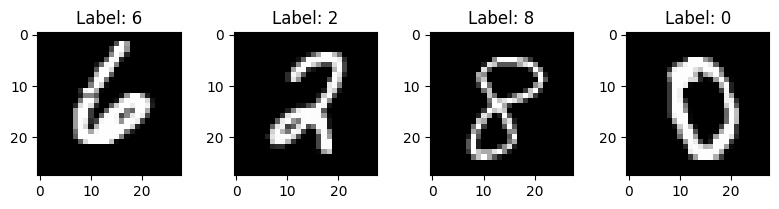

In [10]:
batch_size = 4
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
# grab one batch
images, labels = next(iter(test_dataloader)) 
figure = plt.figure(figsize=(8, 2))
for i in range(batch_size):
    # i + 1 because matplotlib subplots are 1-indexed (1 to 16)
    ax = figure.add_subplot(1, batch_size, i + 1)
    plt.title(f"Label: {labels[i].item()}")
    # Squeeze turns [1, 28, 28] into [28, 28] for grayscale display
    plt.imshow(images[i].squeeze(), cmap="gray")
plt.tight_layout()
plt.show()

## create the model
PyTorch follows the same convention as linear regression where we write
$$
Y = X\beta + \epsilon
$$

note that the bias can be absorbed by adding an identity column to $X$. The weight matrix $W$ corresponds to $\beta^T$
\begin{align}
X &\in \mathbb{R}^{N \times p} 
    && \text{(batch of $N$ samples, each with $p$ features)} \\
W &\in \mathbb{R}^{K \times p} 
    && \text{(weight matrix: $K$ outputs, $p$ input features)} \\
b &\in \mathbb{R}^{K} 
    && \text{(bias vector, one per output)} \\
Y &= X W^\top + b \in \mathbb{R}^{N \times K} 
    && \text{(predicted outputs for $N$ samples, $K$ outputs per sample)}
\end{align}

**Batch-as-rows (PyTorch / linear regression style):**

$$\boxed{
X \in \mathbb{R}^{N \times p}, \quad 
W \in \mathbb{R}^{K \times p}, \quad 
b \in \mathbb{R}^{K}, \quad
Y = X W^\top + b \in \mathbb{R}^{N \times K}}
$$

**Column vector view (classic neural network derivation):**

$$
x_i \in \mathbb{R}^{p}, \quad 
Y_i = W x_i + b \in \mathbb{R}^{K}, \quad
\text{or collectively: } Y^T = W X^T + b^T
$$

**Notes:**  
- $N$ = batch size / number of data points (rows in $X$)  
- $p$ = input features per sample  
- $K$ = number of outputs  
- In the row-batch view, weights multiply from the right and outputs are rows.  
- In the column-vector view, weights multiply from the left and outputs are column vectors.


We will create a neural net with a single hidden layer, using the conventions we defined above. Starting with the flattened image vector as the input $x^{(0)}$

$$\begin{aligned}
\mathbf{x}^{(0)} &= \text{vec}(\text{Input Image}) \in \mathbb{R}^{784} \\
\mathbf{z}^{(1)} &= \mathbf{W}^{(1)} \mathbf{x}^{(0)} + \mathbf{b}^{(1)} \\
\mathbf{x}^{(1)} &= \text{GELU}(\mathbf{z}^{(1)}) \\
\mathbf{z}^{(2)} &= \mathbf{W}^{(2)} \mathbf{x}^{(1)} + \mathbf{b}^{(2)} \\
\mathbf{\hat{y}} &= \text{Softmax}(\mathbf{z}^{(2)})
\end{aligned}$$

**Important note for numerical implementation:** For classification problems, we will use cross-entropy as the loss function. Note that this description of the neural net below is missing the softmax. For numerical stability reasons, softmax is incorporated into cross-entropy to avoid exploding gradients. Model will always output the raw, unnormalized logits - and when we make inference we need to apply it manually and pick the output with the largest probability. See the discussion at the bottom for a deeper dive.

**Class indices input for cross entropy loss function:** pytorch will accept class indices such as integers for labeling (see [`nn.CrossEntropyLoss`][1]) This is more memory efficient than passing sparsely one-hot-encoded unit vectors as labels. 

[1]:http://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

In [11]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # initiate the flattener from the class
        # this keeps the first dimension as the batch dimension
        # batch dimension means the dimension along which data is aligned
        self.flatten = nn.Flatten() 
        self.stack = nn.Sequential(
            nn.Linear(28*28,28), # Y = XW.T + b
            nn.GELU(),
            nn.Linear(28,10)
        )
    def forward(self, x):
        x = self.flatten(x)
        y_pred = self.stack(x)
        return y_pred

the flattening is there to handle higher dimensional data, such as an array of images which would have the shape $(T,N,N)$ where $T$ is the number of images (corresponds to the batch dimension) and each image would be $N$ by $N$ pixels.


In [12]:
model = NeuralNetwork()
model = model.to(device)
# training data - pick a batch size that's a power of 2
training_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
# validation data - single megabatch to evaluate the model during training.
test_dataloader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)
val_inputs, val_labels = next(iter(test_dataloader))
val_inputs, val_labels = val_inputs.to(device), val_labels.to(device) 

Epoch 3, training loss: 0.2559
Epoch 3, validation loss: 0.2377 | accuracy: : 0.9317
Epoch 6, training loss: 0.1825
Epoch 6, validation loss: 0.1765 | accuracy: : 0.9480
Epoch 9, training loss: 0.1442
Epoch 9, validation loss: 0.1485 | accuracy: : 0.9552
Epoch 12, training loss: 0.1198
Epoch 12, validation loss: 0.1355 | accuracy: : 0.9601
Epoch 15, training loss: 0.1029
Epoch 15, validation loss: 0.1209 | accuracy: : 0.9640
Epoch 18, training loss: 0.0909
Epoch 18, validation loss: 0.1148 | accuracy: : 0.9640
Epoch 21, training loss: 0.0807
Epoch 21, validation loss: 0.1118 | accuracy: : 0.9659
Epoch 24, training loss: 0.0727
Epoch 24, validation loss: 0.1107 | accuracy: : 0.9670
Epoch 27, training loss: 0.0660
Epoch 27, validation loss: 0.1053 | accuracy: : 0.9683
Epoch 30, training loss: 0.0601
Epoch 30, validation loss: 0.1099 | accuracy: : 0.9685


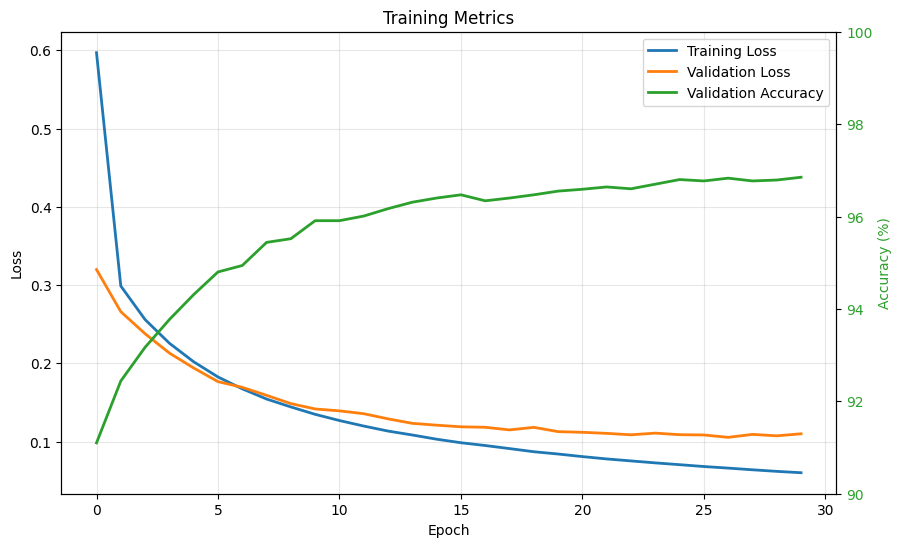

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# --- 5. Minimal training loop ---
tloss = [] #training loss
vloss = [] #validation loss
vacc = [] #accuracy

epochs = 30
for epoch in range(epochs):
    # train on the batches
    epoch_train_loss = 0.0
    total_samples = 0
    # backprop on training set - compute loss
    for inputs, labels in training_dataloader:
        # move to MPS
        inputs = inputs.to(device)
        labels = labels.to(device)

        # do backprop on the batch
        optimizer.zero_grad()            # clear gradients
        outputs = model(inputs)           # forward pass
        loss = loss_fn(outputs, labels)   # compute loss
        loss.backward()                  # backward pass
        optimizer.step()                 # update weights

        epoch_train_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)
    epoch_train_loss /= total_samples
    # compute loss and accuracy on validation for the megabatch
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = loss_fn(val_outputs, val_labels)
        epoch_val_loss = val_loss.item() 
        conf, pred = torch.max(torch.softmax(val_outputs, dim=1), dim=1)
        accuracy = (pred == val_labels).float().mean().item()
    if (epoch+1) % (epochs //10) == 0:
        print(f"Epoch {epoch+1}, training loss: {epoch_train_loss:.4f}")
        print(f"Epoch {epoch+1}, validation loss: {epoch_val_loss:.4f} | accuracy: : {accuracy:.4f}")
    tloss.append(epoch_train_loss)
    vloss.append(epoch_val_loss)
    vacc.append(accuracy*100)

# --- Plotting with Secondary Axis ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Loss
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
line1 = ax1.plot(tloss, label='Training Loss', color='tab:blue', linewidth=2)
line2 = ax1.plot(vloss, label='Validation Loss', color='tab:orange', linewidth=2)
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Secondary Axis: Accuracy
ax2 = ax1.twinx() 
ax2.set_ylabel('Accuracy (%)', color='tab:green')
line3 = ax2.plot(vacc, label='Validation Accuracy', color='tab:green', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(90, 100) # Fixed scale for accuracy

# Combine legends from both axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title('Training Metrics')
plt.show()

## check out some predictions from the validation set

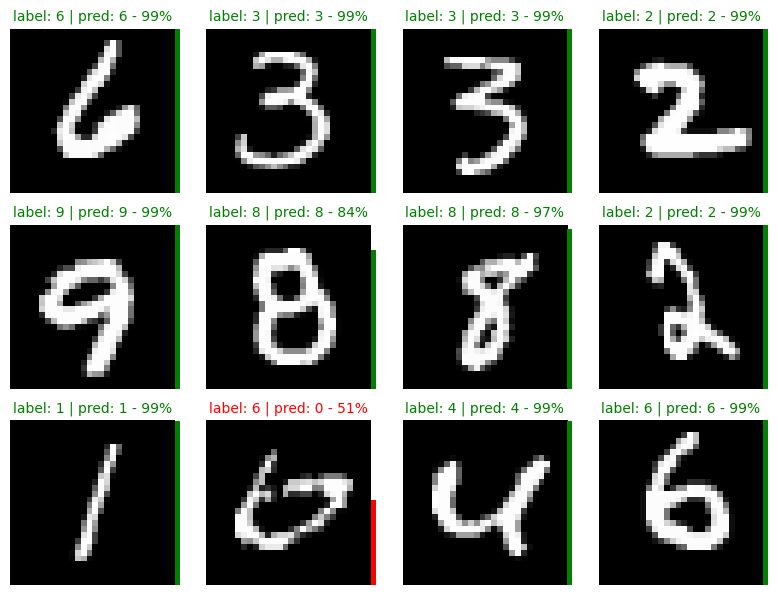

In [14]:
batch_size = 12
from mpl_toolkits.axes_grid1 import make_axes_locatable
# grab sample in dices
indices = torch.randperm(len(test_data))[:batch_size]
# slice both tensors using the same indices
images = val_inputs[indices]
labels = val_labels[indices]
figure = plt.figure(figsize=(8, 2*(batch_size // 4 + 1)))
with torch.no_grad():
    # Forward pass
    logits = model(images)
    # The Handshake: Get confidence (0.0-1.0) and the predicted index
    conf, pred = torch.max(torch.softmax(logits, dim=1), dim=1)

for i in range(batch_size):
    # Logic for correctness
    correct = (pred[i] == labels[i])
    color = "green" if correct else "red"
    
    # Setup subplot
    ax = figure.add_subplot(batch_size // 4 + 1, 4, i + 1)
    
    # Modified Title: Shows Label vs Prediction
    ax.set_title(f"label: {labels[i].item()} | pred: {pred[i].item()} - {int(100*conf[i].item())}%", 
                 color=color, fontsize=10)
    
    # Display the digit
    ax.imshow(images[i].cpu().squeeze(), cmap="gray")
    ax.axis("off") # Clean up the look

    # --- The Confidence Stick Logic ---
    # We use a divider to append a new axis to the right with 0 pad
    divider = make_axes_locatable(ax)
    bar_ax = divider.append_axes("right", size="3%", pad=0.0)
    
    # Calculate the "sliver" height based on confidence
    # We draw a bar from y=0 to y=confidence
    # Since image height is 28, we scale it so confidence 1.0 = full height
    bar_ax.bar([0], [conf[i].item()], color=color, width=1.0)

    # Fix the bar limits so it doesn't "jump" around
    bar_ax.set_xlim(-0.5, 0.5)
    bar_ax.set_ylim(0, 1) # Force scale 0 to 1
    bar_ax.axis("off")

plt.tight_layout()
plt.show()

# log-likelihood and cross entropy for classification problems

#### stating the classification problem
Suppose we have a model that predicts class membership according to a distribution parameterized by $\theta$. For a given input $\mathbf{X}_i$, the model assigns the input to a class $k \in \{1, \dots, K\}$. To represent these categoricl outcomes numerically, we use **one-hot encoding**.

#### one-hot-encoding
Each class $k$ is associated with a unit vector $\mathbf{y}_i \in \mathbb{R}^K$ from the standard basis. Specifically, if observation $i$ belongs to class $k$, the $k$-th element of the vector is set to one and all others to zero:
$$\mathbf{y}_i = \mathbf{e}_k, \quad \text{where } (\mathbf{e}_k)_j = \delta_{kj}$$
Probability that model predict the correct class is
$$p_\theta(\mathbf{\hat{y}_i}=\mathbf{y}_i|\mathbf{X}_i)$$
However, the model yields a prediction for each outcome, which will look like 
$$\hat{\mathbf{y}}_i = [0.05, 0.12, ... ,0.73, 0.08, 0.02]^T$$
where the $k$ th entry of this will be the probability $p_{ik}$ that model assigns input $\mathbf{X_i}$ to class $k$. Consider the following expression $$\prod_{k}p_{ik}^{y_{ik}}$$ and note that $y_{ik}$ has the form
$$y_{ik} = \mathbb{1}(x_i \in \text{class } k) = \begin{cases} 1 & \text{if observation } i \text{ is class } k \\ 0 & \text{otherwise} \end{cases}$$
given the observed value, this expression only picks out the probability of class $k$ only because of the special structure of the vector $\mathbf{y}$ where only one component has the value 1 and all other components are zero. This is just a clever way to write the probability of observing the correct class: $$p_\theta(\mathbf{\hat{y}_i}=\mathbf{y}_i|\mathbf{X}_i) = \prod_{k}p_{ik}^{y_{ik}}$$Let's illustrate this selection mechanism. For example, if the true class is $k=3$
$$\prod_{k=1}^{K} p_{ik}^{y_{ik}} = p_{i1}^0 \cdot p_{i2}^0 \cdot p_{i3}^1 \cdot \dots \cdot p_{iK}^0 = p_{i3}$$
#### likelihood function
Now suppose we make a set of observations $i=1,..,N$. Assuming independence of observations, the probability of making these observations according to our model is the product of individual observations - called **the likelihood**, is given by $$L(\theta) = \prod_i p_\theta(\mathbf{\hat{y}_i}=\mathbf{y}_i|\mathbf{X}_i) = \prod_{k}p_{ik}^{y_{ik}}$$the key idea is to maximize this function with respect to parameters of the model or the underlying probability distribution so that the our model becomes a better description of the data. **Important to remember that this assumes that all observations are independent. If we are considering time series or other correlated data - note that this assumption is invalidated or has to be justified by other means.**

It is convenient to work with the logarithm of this function, since this is a product of many numbers smaller than one - so it ends up being a very small number for large samples, which might lead to **arithmetic underflow**: numbers being too small for computers to handle. Therefore we define the **log-likelihood**$$\log L(\theta) = \sum_{i=1}^n \sum_{k=1}^K y_{ik} \log(p_{ik})$$ where 
- $y_{ik}$ : $k$ th component of the $i$ th label
- $p_{ik}$ : model predicts that the input $i$ will be in the $k$ th class with this probability

The probabilities are obtained, with some interpretation, by constraining the outputs of a model which can be expressed in the following way: $$p_{ik} = \text{Softmax}(f(\mathbf{X}_i; \theta))_k :=  \frac{\exp(f_k(\mathbf{X}_i; \theta))}{\sum_{j=1}^K \exp(f_j(\mathbf{X}_i; \theta))}$$given an input $\mathbf{X}_i$ model will output a vector $f(\mathbf{X}_i; \theta)$ with components being the unnormalized, raw scores called **logits** for class $k$ and the **softmax** is the function that normalizes these scores and converts them into probabilities. **Here we make the assertion that the numbers generated by softmax are interpreted as probabilities $p_{ik}$**
### always combine log-likelihood and softmax in gradient descent 
**Caveat: exploding gradients!:** log likelihood is very sensitive to outliers. Lets consider a the contribution of a single data point to the log likelihood (suppressing the index $i$ for clarity) $$\ell_i = \log(L_i) = \sum_{k=1}^K y_{k} \log(p_{k})$$if we were to do backprop for gradient descent, we would have to compute $$\frac{\partial \ell_i}{\partial f_l} = \sum_{k=1}^K \frac{\partial \ell_i}{\partial p_k} \cdot \frac{\partial p_k}{\partial f_l}$$note that the first factor $$\frac{\partial \ell_i}{\partial p_k} = \frac{y_k}{p_k}$$explodes as $p_k \rightarrow 0$. Fortunately this is countered by the second factor provided it is defined by **softmax** as described above. The derivative of the softmax output $p_k$ with respect to a logit $f_l$ is given by:$$\frac{\partial p_k}{\partial f_l} = p_k(\delta_{kl} - p_l)$$as the model becomes confident ($p_k \to 0$ or $p_k \to 1$), the term $p_k(\delta_{kl} - p_l)$ **vanishes** toward zero. Combining the two contributions $$\frac{\partial \ell_i}{\partial f_l}  = \sum_{k=1}^K y_k(\delta_{kl} - p_l) = y_{il} - p_{il}$$where we use the one-hot-encoding property $\sum y_k = 1$ and reintroduced the suppressed index. 

The total gradient of the log-likelihood with respect to the logits $f_k$ is the sum of the residual errors across all observations: $$\nabla_{f} \log(L) = \sum_{i=1}^n (\mathbf{y}_i - \mathbf{p}_i)$$where $\mathbf{p}_i$ is the predicted probabilities for sample $i$. By utilizing the fused softmax-cross-entropy operator, we ensure that even with thousands of points and extremely low-probability outliers, the total gradient remains numerically stable and bounded, preventing the catastrophic 'NaN' errors that would occur if the $1/p$ and $p(1-p)$ terms were evaluated independently." So when we do this computation in pytorch - softmax should never be applied to the network outputs, instead work with raw scores, or logits and use the `torch.nn.CrossEntropyLoss`





